In [138]:
import pandas as pd
import numpy as np

In [139]:
train = pd.read_csv('train.csv')

In [140]:
test = pd.read_csv('test.csv')

In [141]:
train.shape

(24000, 25)

In [142]:
train.head

<bound method NDFrame.head of              client_id  LIMIT_BAL  SEX  ...  PAY_AMT5  PAY_AMT6  default
0      CC_0000F52C3717      50000    2  ...      1474      2300        0
1      CC_0008C4E44BB9     150000    2  ...         0         0        0
2      CC_000B4B1BEDF6     450000    2  ...         0      3648        0
3      CC_000D492CE7AD     230000    2  ...      3500      4000        0
4      CC_000DCFA992C4     160000    2  ...     12752      6000        0
...                ...        ...  ...  ...       ...       ...      ...
23995  CC_FFF7FD14A18A      20000    2  ...         0         0        0
23996  CC_FFF97318AFBF     200000    1  ...       541       541        0
23997  CC_FFFB28EA5580     250000    2  ...       396       396        0
23998  CC_FFFD3A829DD0      20000    2  ...      1000         0        0
23999  CC_FFFEDC33E37A     290000    1  ...         0       416        0

[24000 rows x 25 columns]>

In [143]:
train.isnull().sum()

client_id    0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64

In [144]:
train.duplicated().sum()

np.int64(0)

In [145]:
train["default"].value_counts(normalize=True)*100

default
0    77.879167
1    22.120833
Name: proportion, dtype: float64

In [146]:
x = train.drop(columns=["default"])
y = train["default"]
x_test = test.drop(columns=["client_id"])

In [147]:
x = x.drop(columns=["client_id"])

In [148]:
x.shape

(24000, 23)

In [149]:
print(train.info())

<class 'pandas.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   client_id  24000 non-null  str  
 1   LIMIT_BAL  24000 non-null  int64
 2   SEX        24000 non-null  int64
 3   EDUCATION  24000 non-null  int64
 4   MARRIAGE   24000 non-null  int64
 5   AGE        24000 non-null  int64
 6   PAY_0      24000 non-null  int64
 7   PAY_2      24000 non-null  int64
 8   PAY_3      24000 non-null  int64
 9   PAY_4      24000 non-null  int64
 10  PAY_5      24000 non-null  int64
 11  PAY_6      24000 non-null  int64
 12  BILL_AMT1  24000 non-null  int64
 13  BILL_AMT2  24000 non-null  int64
 14  BILL_AMT3  24000 non-null  int64
 15  BILL_AMT4  24000 non-null  int64
 16  BILL_AMT5  24000 non-null  int64
 17  BILL_AMT6  24000 non-null  int64
 18  PAY_AMT1   24000 non-null  int64
 19  PAY_AMT2   24000 non-null  int64
 20  PAY_AMT3   24000 non-null  int64
 21  PAY_AMT4   24000 non-nu

In [150]:
train.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
count,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,2.400000e+04,24000.000000,24000.000000,24000.000000,24000.000000,2.400000e+04,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000
mean,167608.736667,1.601792,1.850708,1.547958,35.540708,-0.019875,-0.137042,-0.168542,-0.225000,-0.269667,-0.296542,51190.568667,49051.114833,4.685905e+04,43175.799292,40271.754333,38743.087125,5711.710125,5.955190e+03,5262.745792,4853.362792,4749.935125,5161.937458,0.221208
std,130130.702503,0.489539,0.795213,0.521898,9.255129,1.125514,1.199960,1.202787,1.172113,1.135635,1.151988,73864.760063,71235.885503,6.955117e+04,64534.910992,60980.478739,59707.335820,17155.309436,2.435021e+04,18426.028570,15752.040523,14873.057360,17925.431411,0.415069
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-65167.000000,-61372.000000,-209051.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3481.750000,2935.000000,2.570500e+03,2300.750000,1710.250000,1206.000000,992.500000,7.800000e+02,390.000000,298.750000,212.750000,100.000000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22435.500000,21190.500000,2.001050e+04,18932.000000,18021.500000,16926.500000,2100.000000,2.000000e+03,1800.000000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67002.500000,63635.000000,5.985700e+04,54341.500000,49937.500000,48904.750000,5004.000000,5.000000e+03,4500.000000,4001.250000,4005.000000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,75.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.000000,621000.000000,417990.000000,528666.000000,1.000000


In [151]:
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    print("\n", col)
    print(train[col].value_counts().sort_index())


 SEX
SEX
1     9557
2    14443
Name: count, dtype: int64

 EDUCATION
EDUCATION
0       10
1     8551
2    11151
3     3911
4       97
5      237
6       43
Name: count, dtype: int64

 MARRIAGE
MARRIAGE
0       42
1    11019
2    12685
3      254
Name: count, dtype: int64


In [152]:
for col in ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]:
    print("\n", col)
    print(train[col].value_counts().sort_index())


 PAY_0
PAY_0
-2     2241
-1     4561
 0    11739
 1     2944
 2     2147
 3      262
 4       56
 5       18
 6       11
 7        6
 8       15
Name: count, dtype: int64

 PAY_2
PAY_2
-2     3061
-1     4848
 0    12543
 1       23
 2     3137
 3      261
 4       78
 5       23
 6        9
 7       16
 8        1
Name: count, dtype: int64

 PAY_3
PAY_3
-2     3322
-1     4747
 0    12540
 1        4
 2     3075
 3      187
 4       64
 5       18
 6       19
 7       21
 8        3
Name: count, dtype: int64

 PAY_4
PAY_4
-2     3538
-1     4547
 0    13096
 1        2
 2     2541
 3      144
 4       53
 5       28
 6        4
 7       45
 8        2
Name: count, dtype: int64

 PAY_5
PAY_5
-2     3688
-1     4425
 0    13503
 2     2111
 3      144
 4       65
 5       15
 6        4
 7       44
 8        1
Name: count, dtype: int64

 PAY_6
PAY_6
-2     3984
-1     4571
 0    12989
 2     2206
 3      143
 4       43
 5       11
 6       18
 7       34
 8        1
Name: count, dtype

In [153]:
train.groupby("default")["LIMIT_BAL"].mean()


default
0    178055.855759
1    130828.344321
Name: LIMIT_BAL, dtype: float64

In [154]:
train.groupby("default")["AGE"].mean()

default
0    35.479857
1    35.754944
Name: AGE, dtype: float64

In [155]:
train.groupby("default")["PAY_0"].mean()

default
0   -0.214970
1    0.666981
Name: PAY_0, dtype: float64

In [156]:
cols = [
    "LIMIT_BAL",
    "AGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

train.groupby("default")[cols].mean()

,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
default,,,,,,,,
0,178055.855759,35.479857,-0.214970,-0.305655,-0.322294,-0.361297,-0.395591,-0.413087
1,130828.344321,35.754944,0.666981,0.456583,0.372763,0.254850,0.173667,0.113769


In [157]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [158]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['LIMIT_BAL','SEX','EDUCATION',...,'PAY_AMT4','PAY_AMT5','PAY_AMT6']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [159]:
logistic_prob = logistic_model.predict_proba(x_val)[:, 1]

In [160]:
from sklearn.metrics import roc_auc_score

logistic_auc = roc_auc_score(y_val, logistic_prob)
print(logistic_auc)

from sklearn.metrics import average_precision_score
logistic_pr = average_precision_score(y_val, logistic_prob)
print(logistic_pr)


0.7177842920320543
0.4867641568172925


In [161]:
train_fe = train.copy()
bill_cols = [
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6"
]

train_fe["TOTAL_BILL"] = train_fe[bill_cols].sum(axis=1)
train_fe["AVG_BILL"] = train_fe[bill_cols].mean(axis = 1)

payment_cols = [
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]
train_fe["TOTAL_PAYMENT"] = train_fe[payment_cols].sum(axis=1)
train_fe["AVG_PAYMENT"] = train_fe[payment_cols].mean(axis=1)

In [162]:
for i in range(1, 7):
    train_fe[f"UTIL_{i}"] = (train_fe[f"BILL_AMT{i}"] / (train_fe["LIMIT_BAL"] +1))

util_cols = [f"UTIL_{i}" for i in range(1, 7)]

train_fe["AVG_UTIL"] = train_fe[util_cols].mean(axis=1)
train_fe["MAX_UTIL"] = train_fe[util_cols].max(axis=1)

print(train_fe)

             client_id  LIMIT_BAL  SEX  ...    UTIL_6  AVG_UTIL  MAX_UTIL
0      CC_0000F52C3717      50000    2  ...  0.819824  0.813137  0.844503
1      CC_0008C4E44BB9     150000    2  ...  0.010180  0.086784  0.253678
2      CC_000B4B1BEDF6     450000    2  ...  0.000000  0.027642  0.038922
3      CC_000D492CE7AD     230000    2  ...  0.402090  0.470513  0.515072
4      CC_000DCFA992C4     160000    2  ...  0.079700  0.080778  0.118487
...                ...        ...  ...  ...       ...       ...       ...
23995  CC_FFF7FD14A18A      20000    2  ...  0.000000  0.012433  0.074596
23996  CC_FFF97318AFBF     200000    1  ...  0.002705  0.003156  0.005410
23997  CC_FFFB28EA5580     250000    2  ...  0.001584  0.003427  0.012640
23998  CC_FFFD3A829DD0      20000    2  ...  0.999950  0.937245  0.999950
23999  CC_FFFEDC33E37A     290000    1  ...  0.001434  0.140959  0.180455

[24000 rows x 37 columns]


In [163]:
for i in range(1, 7):
    train_fe[f"PAY_RATIO_{i}"] = (
        train_fe[f"PAY_AMT{i}"] /
        (train_fe[f"BILL_AMT{i}"].abs() + 1))

ratio_cols = [f"PAY_RATIO_{i}" for i in range(1, 7)]
train_fe["AVG_PAY_RATIO"] = train_fe[ratio_cols].mean(axis=1)

print(train_fe)

             client_id  LIMIT_BAL  SEX  ...  PAY_RATIO_5  PAY_RATIO_6  AVG_PAY_RATIO
0      CC_0000F52C3717      50000    2  ...     0.036678     0.056107       0.044927
1      CC_0008C4E44BB9     150000    2  ...     0.000000     0.000000    3100.013831
2      CC_000B4B1BEDF6     450000    2  ...     0.000000  3648.000000     608.348446
3      CC_000D492CE7AD     230000    2  ...     0.034701     0.043252       0.042242
4      CC_000DCFA992C4     160000    2  ...     1.036917     0.470478       1.013573
...                ...        ...  ...  ...          ...          ...            ...
23995  CC_FFF7FD14A18A      20000    2  ...     0.000000     0.000000     248.666667
23996  CC_FFF97318AFBF     200000    1  ...     0.998155     0.998155       0.998155
23997  CC_FFFB28EA5580     250000    2  ...     0.997481     0.997481       2.012483
23998  CC_FFFD3A829DD0      20000    2  ...     0.052629     0.000000       0.052015
23999  CC_FFFEDC33E37A     290000    1  ...     0.000000     0.99

In [164]:
pay_status_cols = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

In [165]:
train_fe["AVG_PAY_STATUS"] = (
    train_fe[pay_status_cols].mean(axis=1)
)

In [166]:
train_fe["MAX_PAY_STATUS"] = (
    train_fe[pay_status_cols].max(axis=1)
)

In [167]:
train_fe["NUM_DELAY"] = (
    train_fe[pay_status_cols] > 0
).sum(axis=1)

In [168]:
x_fe = train_fe.drop(
    columns=["default", "client_id"]
)

y_fe = train_fe["default"]

In [169]:
x_train_fe, x_val_fe, y_train_fe, y_val_fe = train_test_split(
    x_fe,
    y_fe,
    test_size=0.2,
    random_state=42,
    stratify=y_fe
)

In [170]:
logistic_fe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_fe.fit(x_train_fe, y_train_fe)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](45,)","['LIMIT_BAL','SEX','EDUCATION',...,'AVG_PAY_STATUS','MAX_PAY_STATUS', 'NUM_DELAY']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,45
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [171]:
logistic_fe_prob = logistic_fe.predict_proba(x_val_fe)[:, 1]

In [172]:
print(
    "ROC-AUC:",
    roc_auc_score(y_val_fe, logistic_fe_prob)
)
print(
    "PR-AUC:",
    average_precision_score(y_val_fe, logistic_fe_prob)
)

ROC-AUC: 0.7533517173347681
PR-AUC: 0.49234859072552867


In [173]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train_fe, y_train_fe)
rf_prob = rf.predict_proba(x_val_fe)[:, 1]

In [174]:
print(
    "ROC-AUC:",
    roc_auc_score(y_val_fe, rf_prob)
)

print(
    "PR-AUC:",
    average_precision_score(y_val_fe, rf_prob)
)

ROC-AUC: 0.7655993214696318
PR-AUC: 0.5173337157912528


In [175]:
importance = pd.Series(
    rf.feature_importances_,
    index=x_train_fe.columns
).sort_values(ascending=False)

print(importance.head(15))

PAY_0             0.056545
AVG_PAY_STATUS    0.045046
AGE               0.038820
MAX_PAY_STATUS    0.031796
LIMIT_BAL         0.031034
AVG_PAY_RATIO     0.027468
MAX_UTIL          0.027312
NUM_DELAY         0.026615
AVG_PAYMENT       0.026098
AVG_UTIL          0.026000
UTIL_1            0.025742
TOTAL_PAYMENT     0.025373
UTIL_2            0.024253
BILL_AMT1         0.023503
UTIL_3            0.023347
dtype: float64


<Axes: >

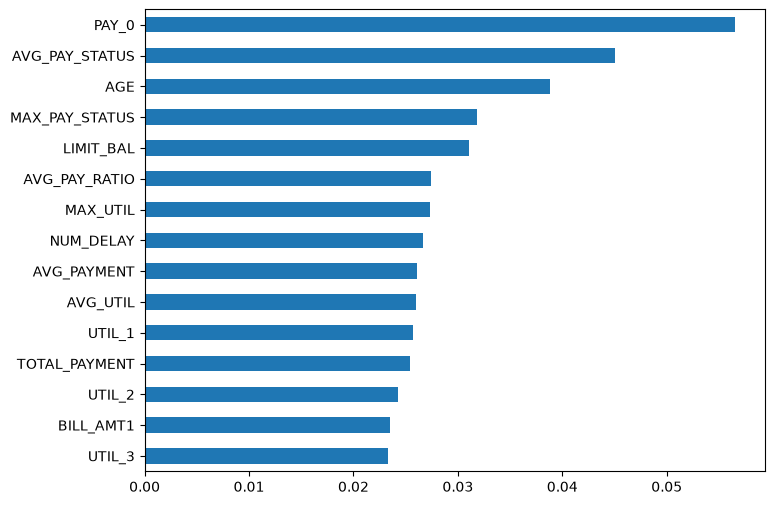

In [176]:
importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)


In [177]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 9.3 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [178]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(x_train_fe, y_train_fe)


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [179]:
xgb_prob = xgb.predict_proba(x_val_fe)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(y_val_fe, xgb_prob)
)

print(
    "PR-AUC:",
    average_precision_score(y_val_fe, xgb_prob)
)


ROC-AUC: 0.7775098771813683
PR-AUC: 0.5406304242135472


In [ ]:
comparison_data = [
    {
        "Model": "Logistic Regression",
        "ROC-AUC": roc_auc_score(y_val, logistic_prob),
        "PR-AUC": average_precision_score(y_val, logistic_prob)
    },
    {
        "Model": "Logistic + features",
        "ROC-AUC": roc_auc_score(y_val_fe, logistic_fe_prob),
        "PR-AUC": average_precision_score(y_val_fe, logistic_fe_prob)
    },
    {
        "Model": "Random Forest",
        "ROC-AUC": roc_auc_score(y_val_fe, rf_prob),
        "PR-AUC": average_precision_score(y_val_fe, rf_prob)
    },
    {
        "Model": "XGBoost",
        "ROC-AUC": roc_auc_score(y_val_fe, xgb_prob),
        "PR-AUC": average_precision_score(y_val_fe, xgb_prob)
    }
]

# Convert to Pandas DataFrame
comparison_df = pd.DataFrame(comparison_data)

comparison_df["ROC-AUC"] = comparison_df["ROC-AUC"].round(4)
comparison_df["PR-AUC"] = comparison_df["PR-AUC"].round(4)

# Display the table
print("------ Model Comparison Table ------")
print(comparison_df.sort_values(by="ROC-AUC", ascending=False).to_string(index=False))

------ Model Comparison Table ------
              Model  ROC-AUC  PR-AUC
            XGBoost   0.7768  0.5337
      Random Forest   0.7654  0.5178
Logistic + features   0.7534  0.4923
Logistic Regression   0.7178  0.4868


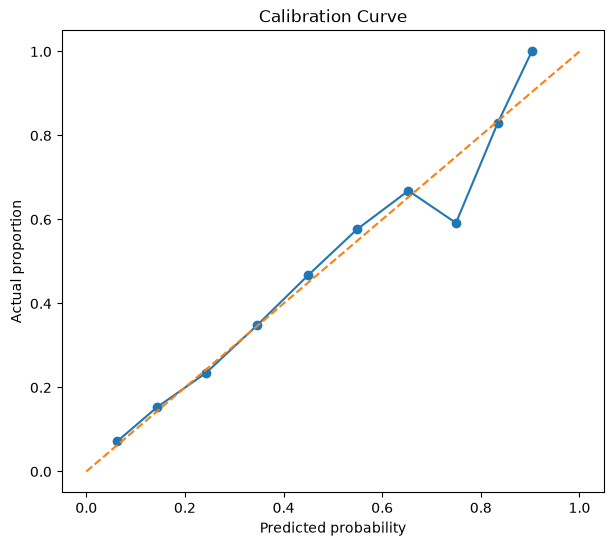

In [180]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_val_fe,
    xgb_prob,
    n_bins=10
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("Predicted probability")
plt.ylabel("Actual proportion")
plt.title("Calibration Curve")

plt.show()

In [181]:
train.groupby("SEX")["default"].mean()
train.groupby("EDUCATION")["default"].mean()
train.groupby("MARRIAGE")["default"].mean()
train["AGE_GROUP"] = pd.cut(
    train["AGE"],
    bins=[0, 25, 35, 45, 55, 100]
)
train.groupby("AGE_GROUP", observed=True)["default"].mean()

AGE_GROUP
(0, 25]      0.264564
(25, 35]     0.197780
(35, 45]     0.222092
(45, 55]     0.245955
(55, 100]    0.255072
Name: default, dtype: float64

In [182]:
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [183]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [184]:
scores = cross_val_score(
    xgb,
    x_fe,
    y_fe,
    cv=cv,
    scoring="roc_auc"
)

print(scores)
print(scores.mean())
print(scores.std())

[0.775721   0.78494648 0.80053119 0.78889357 0.783098  ]
0.7866380505564801
0.008156984977880586
